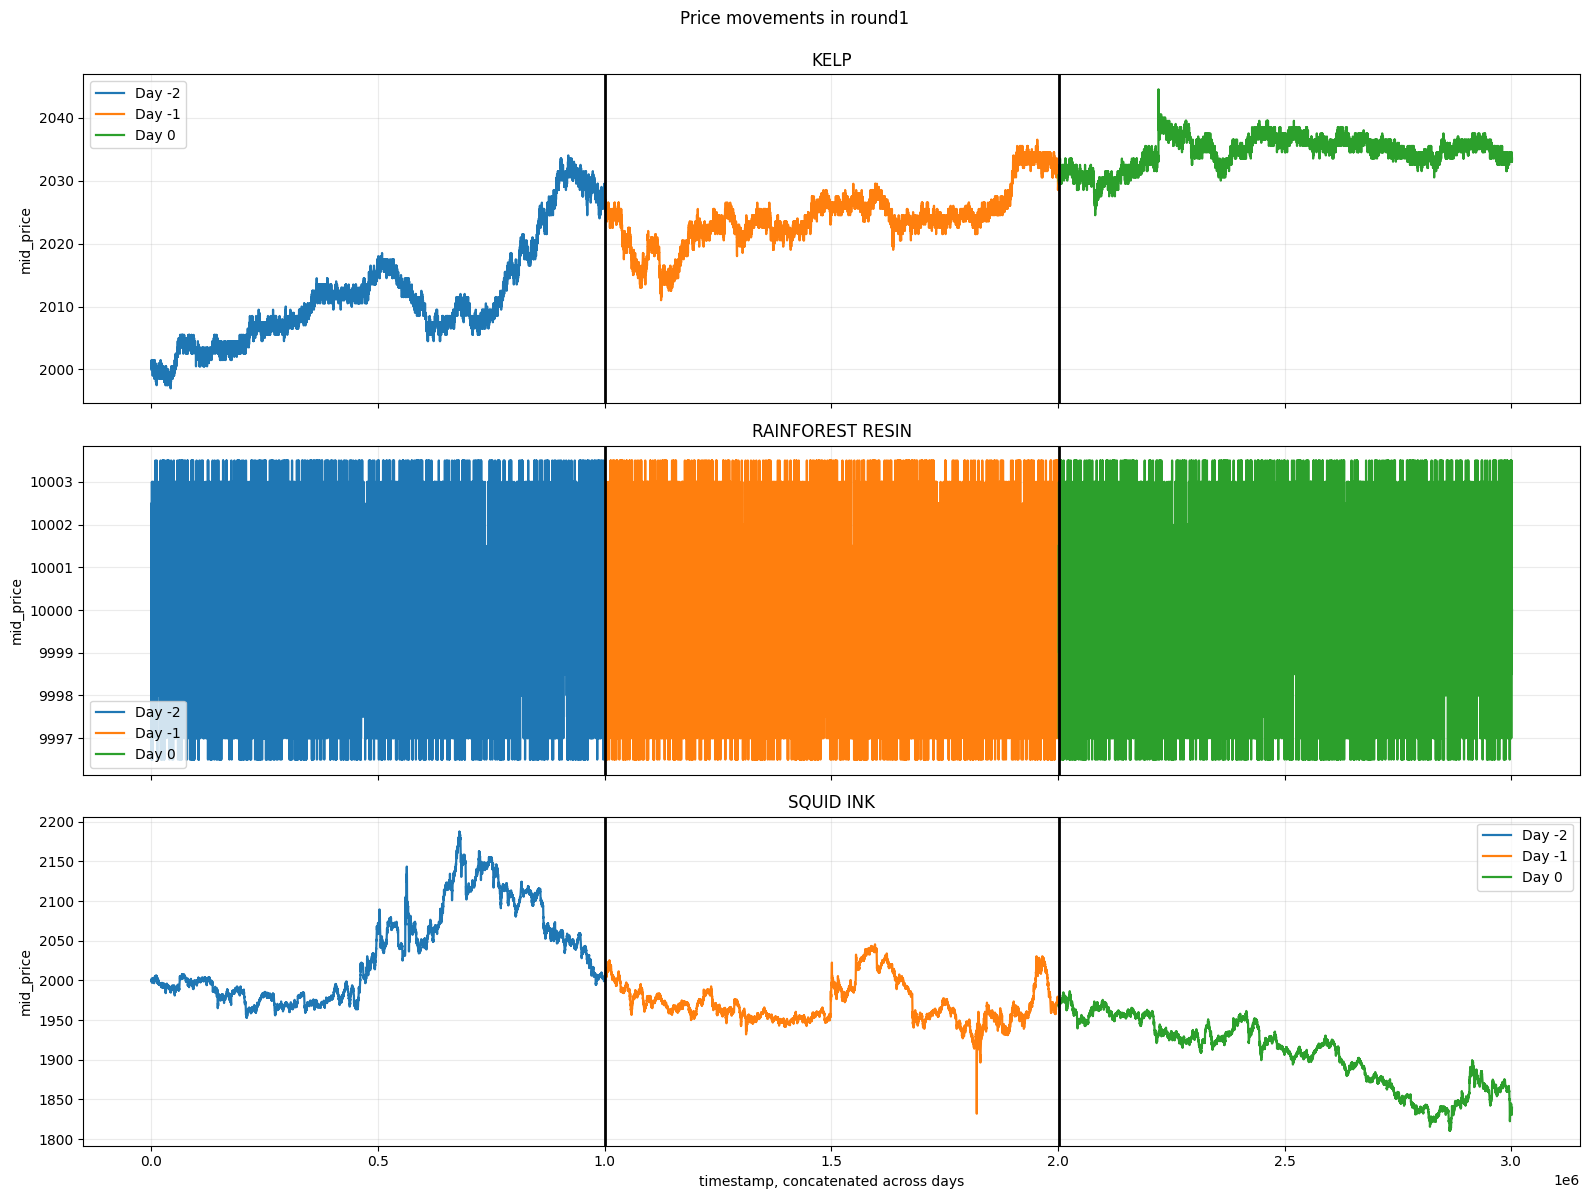

In [6]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd

ROUND_NUMBER = 1
candidate_folders = [
    Path(f"round{ROUND_NUMBER}"),
    Path("2025") / f"round{ROUND_NUMBER}",
]
ROUND_FOLDER = next((folder for folder in candidate_folders if folder.exists()), None)
if ROUND_FOLDER is None:
    raise FileNotFoundError(f"Could not find the round{ROUND_NUMBER} folder. Tried: round{ROUND_NUMBER}, 2025/round{ROUND_NUMBER}")

PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
products = sorted(prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = prices[prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = prices[prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


0


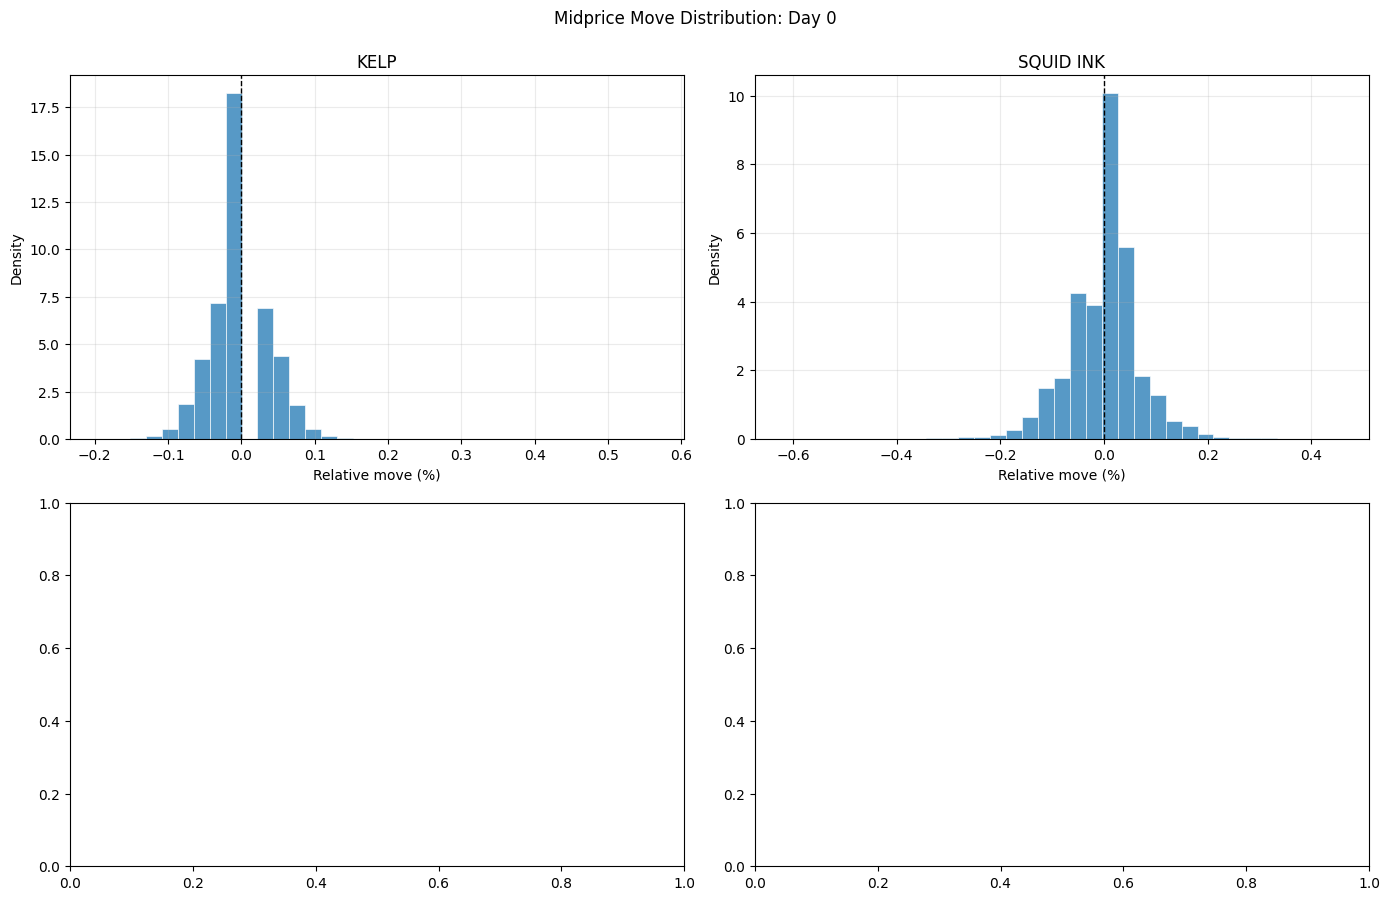

1


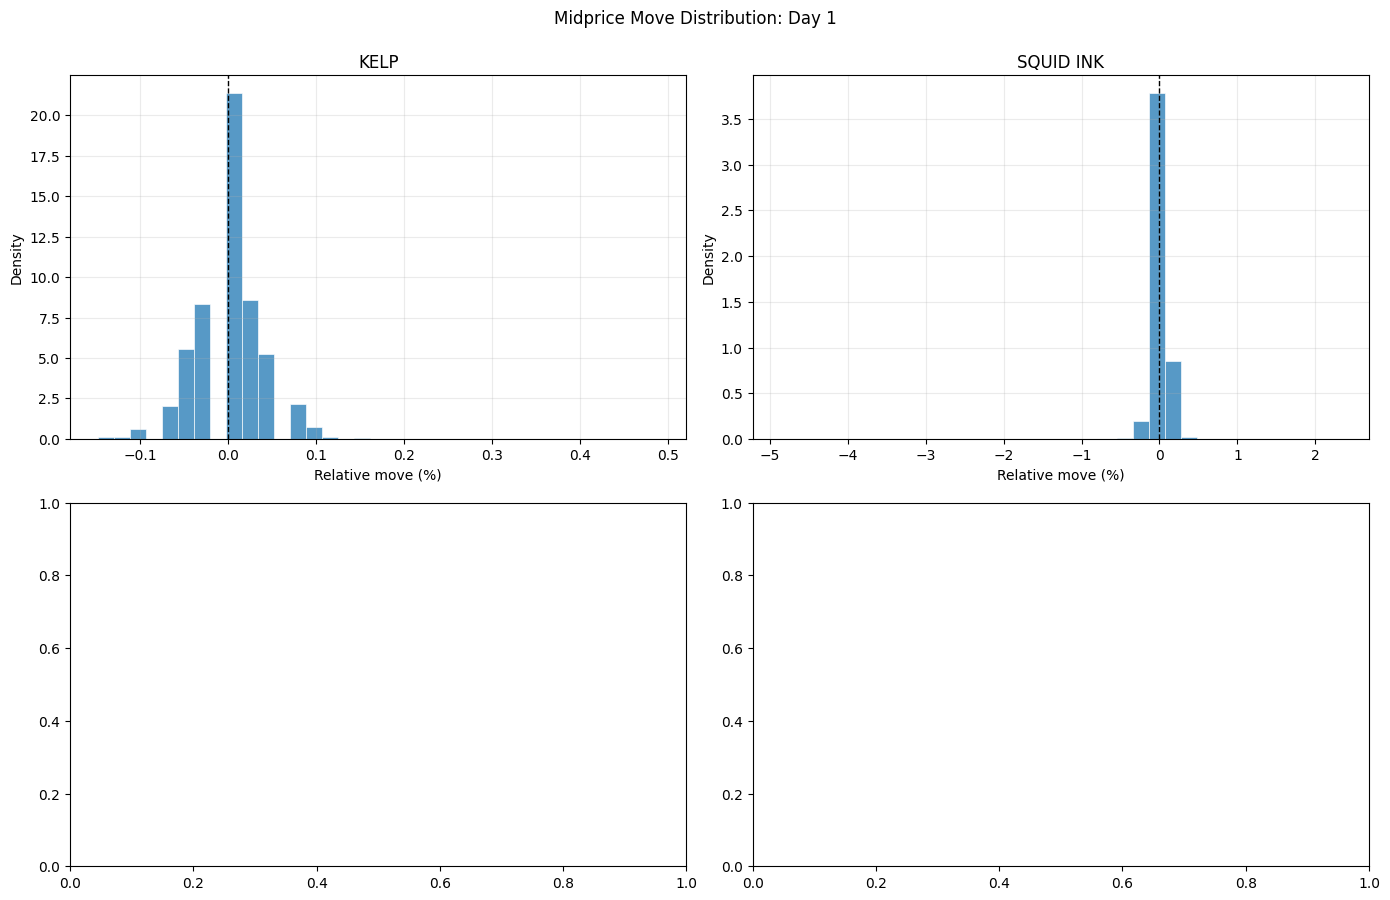

2


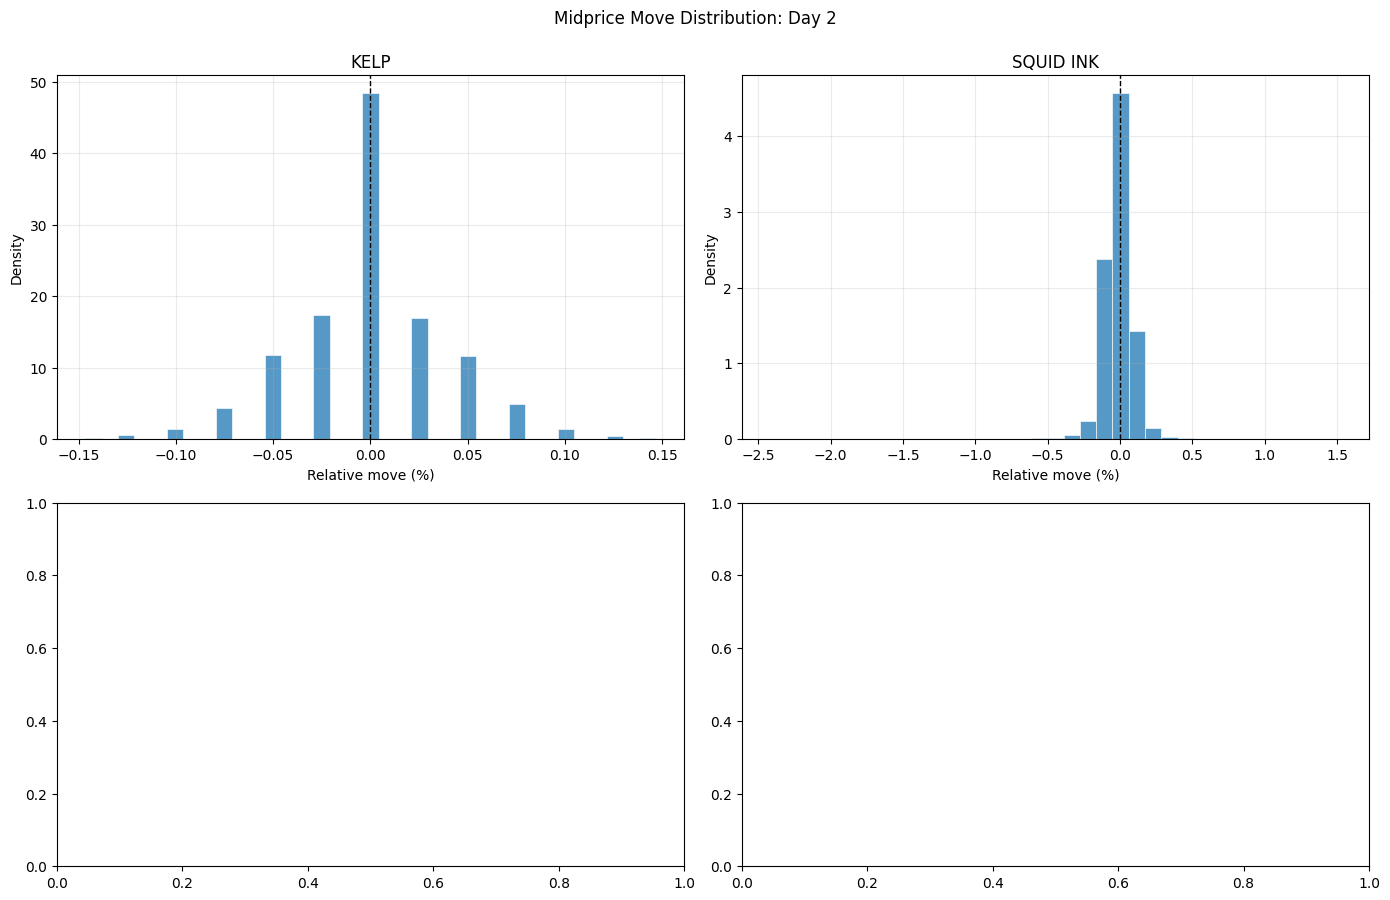

,product,timestamp,rel_move,curr_day
0,KELP,100,0.000493,0
1,KELP,200,-0.000246,0
2,KELP,300,0.000000,0
3,KELP,400,-0.000492,0
4,KELP,500,0.000000,0


In [1]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROUND_NUMBER = 3
TARGET_PRODUCTS = ["KELP", "SQUID_INK"]

candidate_folders = [
    Path(f"round{ROUND_NUMBER}"),
    Path("2025") / f"round{ROUND_NUMBER}",
]
round_folder = next((folder for folder in candidate_folders if folder.exists()), None)
if round_folder is None:
    raise FileNotFoundError(
        f"Could not find round{ROUND_NUMBER} data folder. Tried: round{ROUND_NUMBER}, 2025/round{ROUND_NUMBER}"
    )

price_files = sorted(round_folder.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not price_files:
    raise FileNotFoundError(f"No files matching prices_round_{ROUND_NUMBER}_day_x.csv in {round_folder}")

day_re = re.compile(r"day_(-?\d+)\.csv$")
frames = []
for file_path in price_files:
    match = day_re.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    df = pd.read_csv(file_path, sep=";")
    df = df[df["product"].isin(TARGET_PRODUCTS)].copy()
    df["day"] = day
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

prices = pd.concat(frames, ignore_index=True)
prices["timestamp"] = pd.to_numeric(prices["timestamp"], errors="coerce")
prices["mid_price"] = pd.to_numeric(prices["mid_price"], errors="coerce")
prices = prices.dropna(subset=["timestamp", "mid_price"])

pivot = prices.pivot_table(
    index=["product", "timestamp"],
    columns="day",
    values="mid_price",
    aggfunc="last",
)

available_days = sorted(pivot.columns.tolist())
if len(available_days) < 2:
    raise ValueError("Need at least two day files to compute movement from previous day.")

moves = []
for i in range(1, len(available_days)):
    prev_day = available_days[i - 1]
    curr_day = available_days[i]

    pair = pivot[[prev_day, curr_day]].dropna().copy()
    pair["rel_move"] = (pair[curr_day] - pair[prev_day]) / pair[prev_day]
    pair = pair.reset_index()[["product", "timestamp", "rel_move"]]
    pair["day_pair"] = f"{prev_day}->{curr_day}"
    moves.append(pair)

moves_df_list = []

# For each day, compute relative moves between consecutive timestamps
for day in available_days:
    day_data = prices[prices["day"] == day]
    intraday_moves = []
    
    for product in TARGET_PRODUCTS:
        prod_data = day_data[day_data["product"] == product].sort_values("timestamp")
        if len(prod_data) > 1:
            # Compute relative moves between consecutive timestamps
            for i in range(1, len(prod_data)):
                prev_price = prod_data.iloc[i - 1]["mid_price"]
                curr_price = prod_data.iloc[i]["mid_price"]
                rel_move = (curr_price - prev_price) / prev_price
                intraday_moves.append({
                    "product": product,
                    "timestamp": prod_data.iloc[i]["timestamp"],
                    "rel_move": rel_move,
                    "curr_day": day,
                })
    
    if intraday_moves:
        moves_df_list.append(pd.DataFrame(intraday_moves))

if not moves_df_list:
    raise ValueError("No valid move data found.")

moves_df = pd.concat(moves_df_list, ignore_index=True)

for curr_day in sorted(moves_df["curr_day"].unique()):
    pair_df = moves_df[moves_df["curr_day"] == curr_day]
    print(curr_day)
    fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=False, sharey=False)
    axes = axes.flatten()

    for ax, product in zip(axes, TARGET_PRODUCTS):
        data = pair_df[pair_df["product"] == product]["rel_move"].dropna()
        if data.empty:
            ax.set_title(product.replace("_", " "))
            ax.text(0.5, 0.5, "No valid overlaps", ha="center", va="center", transform=ax.transAxes)
            ax.set_axis_off()
            continue

        ax.hist(data * 100, bins=35, density=True, alpha=0.75, edgecolor="white", linewidth=0.6)
        ax.axvline(0, color="black", linestyle="--", linewidth=1)
        ax.set_title(product.replace("_", " "))
        ax.set_xlabel("Relative move (%)")
        ax.set_ylabel("Density")
        ax.grid(alpha=0.25)

    fig.suptitle(f"Midprice Move Distribution: Day {curr_day}", y=0.995)
    fig.tight_layout()
    plt.show()

moves_df.head()